**Autor:** Alan Sastre  
**GitHub:** [github.com/alansastre/genai-fundamentos](https://github.com/alansastre/genai-fundamentos)

---

## Google y la familia de modelos Gemini

Google ofrece acceso a sus modelos de inteligencia artificial generativa a través de la familia **Gemini**. Estos modelos destacan por su capacidad multimodal nativa, pudiendo procesar texto, imágenes, audio, video y PDFs en una misma conversación.

La familia Gemini incluye diferentes variantes optimizadas para distintos casos de uso:

### Modelos Gemini 3.0 (última generación)

* **gemini-3-pro-preview**: El modelo más potente de la familia, diseñado para tareas complejas de razonamiento
* **gemini-3-flash-preview**: Balance óptimo entre rendimiento, velocidad y coste. Recomendado para desarrollo
* **gemini-3-pro-image-preview**: Modelo Pro con capacidad de generación de imágenes

### Modelos Gemini 2.5

* **gemini-2.5-pro**: Versión estable anterior, ideal para producción
* **gemini-2.5-flash**: Balance rendimiento/velocidad de la generación 2.5
* **gemini-2.5-flash-image**: Flash 2.5 con capacidad de generación de imágenes
* **gemini-2.5-flash-lite**: Versión optimizada para alta velocidad y bajo coste

> Para desarrollo y pruebas, se recomienda usar **gemini-3-flash-preview** por ser el más actual, rápido y económico de la generación 3.0.

Una característica distintiva de Gemini es su **capacidad multimodal nativa**, permitiendo analizar imágenes, transcribir audio, entender videos e incluso generar imágenes y audio en ciertos modelos.

## Obtener una API key de Google AI

Para utilizar los modelos de Google desde LangChain, necesitas una **API key** que autentique tus peticiones. La forma más rápida de obtenerla es a través de Google AI Studio.

El primer paso es acceder a [aistudio.google.com/api-keys](https://aistudio.google.com/api-keys) con tu cuenta de Google. Desde ahí puedes generar una nueva API key con un solo clic.

Los pasos son:
1. Acceder a Google AI Studio
2. Iniciar sesión con tu cuenta de Google
3. Hacer clic en **Create API key**
4. Copiar y guardar la clave generada

A diferencia de otros proveedores, Google AI Studio permite regenerar o ver las claves existentes en cualquier momento.

> La API key es confidencial y no debe compartirse ni subirse a repositorios públicos. Trátala como una contraseña.

### Plan gratuito y facturación

Google ofrece un **plan gratuito** generoso para experimentar con los modelos Gemini. Este plan incluye un número limitado de peticiones por minuto y por día, suficiente para desarrollo y pruebas.

Para uso en producción o mayor volumen, puedes habilitar la facturación desde Google Cloud Console. Los precios se calculan por millón de tokens de entrada y salida.

## Instalar langchain-google-genai

El paquete **langchain-google-genai** proporciona la integración oficial entre LangChain y los modelos de Google. Se instala de forma independiente al paquete principal de LangChain:

```bash .noeval
pip install langchain-google-genai
```

Este comando instala el SDK de Google GenAI junto con las clases específicas de LangChain para interactuar con Gemini. El paquete se mantiene actualizado con las últimas versiones de la API de Google.

> Si ya tienes instalados otros paquetes de integración como langchain-ollama o langchain-anthropic, todos coexisten sin conflictos. Cada proveedor tiene su propio paquete de integración.

## Configurar y usar ChatGoogleGenerativeAI

La clase **ChatGoogleGenerativeAI** es el punto de entrada para interactuar con los modelos de Google desde LangChain. Para usarla, primero configura tu API key en un archivo `.env`:

```.noeval
GOOGLE_API_KEY=tu-clave-aqui
```

Sustituye `tu-clave-aqui` por la API key que copiaste de Google AI Studio. Con esta configuración, **ChatGoogleGenerativeAI detectará automáticamente** la variable `GOOGLE_API_KEY` (también reconoce `GEMINI_API_KEY`).

In [22]:
from langchain_google_genai import ChatGoogleGenerativeAI

# Instanciar el modelo (la API key se carga automáticamente desde .env)
modelo = ChatGoogleGenerativeAI(model="gemini-3-flash-preview")

# Invocar el modelo
respuesta = modelo.invoke("¿Cuál es la capital de España?")

# Acceder al contenido y metadatos
print(f"Respuesta: {respuesta.content}")
print(f"Tokens de entrada: {respuesta.usage_metadata.get('input_tokens')}")
print(f"Tokens de salida: {respuesta.usage_metadata.get('output_tokens')}")

Respuesta: [{'type': 'text', 'text': 'La capital de España es **Madrid**.', 'extras': {'signature': 'EpwCCpkCAXLI2nwqRd9AXACAyk8N9kC33PTM3akgD2c4pl5A/v1xhA2GLIU3wjadP1pJxUW6BY0971lV+hT94mUvU6ZUgIkF4YCoL/ivrtDjmcajuMDh6n2pXnafUgTDHXvfWTIK74B/AGhMHhrgPRSFl9jjuNKKjUAe//JXoUadH1BxYlmJbkKH2yEAJ9DXQGw/foFwBd6PxMLcPa2i/VvdGgeswglGHM2Wmd5017pYvHgTgJJTDGwPeg9FNq52PsVHjyY9q101Uun72g7e7c7E0/HeFDZWxTRnN03UoHVGHrtj2j/lrD9d6Y6SL4gJh74Y3SY9XLtBFPwbuv9JGW9eCswZY9o8WWdoDynKPm3m3aYI+vcmJEmf5aONncQ='}}]
Tokens de entrada: 9
Tokens de salida: 69


> Añade el archivo `.env` a tu `.gitignore` para evitar subir credenciales a repositorios de código.

El parámetro `model` especifica qué modelo de Gemini utilizar. Los identificadores de modelo siguen un patrón consistente.

### Nomenclatura de modelos

Google utiliza un patrón consistente para nombrar sus modelos:

```
gemini-{version}-{variante}-{sufijo}
```

Por ejemplo, `gemini-3-flash-preview` se descompone en:
* **gemini**: Familia del modelo
* **3**: Versión (3.0 o 2.5)
* **flash**: Variante (flash, pro, flash-lite)
* **preview**: Sufijo opcional (preview para modelos en desarrollo, image para capacidad de generación de imágenes)

> Consulta la [documentación oficial de Google AI](https://ai.google.dev/gemini-api/docs/models) para ver los modelos más recientes y sus especificaciones.

## Usar diferentes modelos

Puedes cambiar entre modelos simplemente modificando el parámetro `model`. Cada modelo tiene características diferentes en términos de velocidad, capacidad y coste:

In [23]:
from langchain_google_genai import ChatGoogleGenerativeAI

pregunta = "Explica la teoría de la relatividad en términos simples"

# Modelo rápido para pruebas (Gemini 3.0)
modelo_flash = ChatGoogleGenerativeAI(model="gemini-3-flash-preview")
print("=== Gemini 3 Flash ===")
print(modelo_flash.invoke(pregunta).content)

# Modelo avanzado para tareas complejas (Gemini 3.0)
modelo_pro = ChatGoogleGenerativeAI(model="gemini-3-pro-preview")
print("\n=== Gemini 3 Pro ===")
print(modelo_pro.invoke(pregunta).content)

=== Gemini 3 Flash ===
[{'type': 'text', 'text': 'La teoría de la relatividad de Albert Einstein suena complicada, pero en realidad se puede resumir en una idea principal: **el tiempo y el espacio no son fijos, sino que cambian dependiendo de quién los mire.**\n\nPara entenderla, hay que dividirla en dos partes:\n\n---\n\n### 1. Relatividad Especial (El tiempo es flexible)\nImagina que vas en un tren que viaja casi a la velocidad de la luz. Einstein descubrió dos cosas asombrosas:\n\n*   **La velocidad de la luz es el límite:** Nada puede ir más rápido que la luz (300,000 km por segundo). No importa si tú estás quieto o corriendo, la luz siempre pasará a la misma velocidad.\n*   **El tiempo se estira:** Si viajaras en ese tren superrápido durante un año y luego volvieras a la Tierra, ¡te darías cuenta de que para tus amigos han pasado 10 años mientras que para ti solo pasó uno! \n    *   *En resumen:* Cuanto más rápido te mueves, más lento pasa el tiempo para ti en comparación con algu

## Generar imágenes

Podemos usar nano banana pro para crear una imagen:

Imagen guardada como prompt_engineering.webp


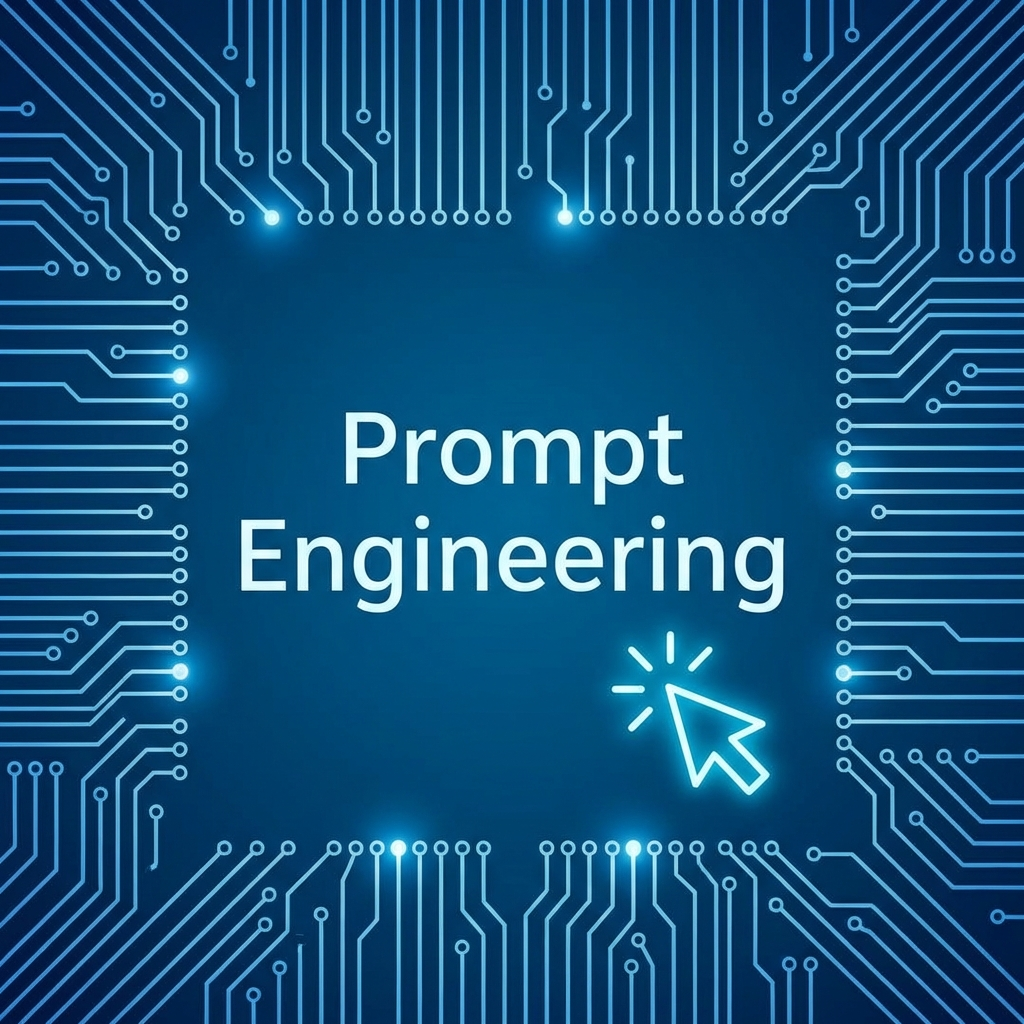

In [24]:
import base64
from io import BytesIO
from PIL import Image

llm = ChatGoogleGenerativeAI(model="gemini-3-pro-image-preview")
response = llm.invoke("Genera una imagen de 250x250 que ponga Prompt Engineering")

# Extraer la imagen del AIMessage y guardarla como webp
for content in response.content:
    if isinstance(content, dict) and content.get("type") == "image_url":
        # Extraer el base64 de la URL (formato: data:image/jpeg;base64,...)
        image_url = content["image_url"]["url"]
        # Separar el header del base64
        base64_data = image_url.split(",")[1]
        # Decodificar base64
        image_bytes = base64.b64decode(base64_data)
        # Abrir con PIL y guardar como webp
        image = Image.open(BytesIO(image_bytes))
        image.save("prompt_engineering.webp", "WEBP")
        print("Imagen guardada como prompt_engineering.webp")
        display(image)

## Conversaciones con mensajes estructurados

Los modelos de Google soportan todos los formatos de mensajes estándar de LangChain. Puedes pasar una lista de tuplas con roles (system, human, ai):

In [25]:
from langchain_google_genai import ChatGoogleGenerativeAI

modelo = ChatGoogleGenerativeAI(model="gemini-3-flash-preview")

# Conversación con system prompt y contexto
mensajes = [
    ("system", "Eres un experto en historia del arte. Responde de forma concisa."),
    ("human", "¿Quién pintó la Mona Lisa?"),
    ("ai", "Leonardo da Vinci pintó la Mona Lisa entre 1503 y 1519."),
    ("human", "¿En qué museo se encuentra actualmente?")
]

respuesta = modelo.invoke(mensajes)
print(respuesta.content)

[{'type': 'text', 'text': 'Se encuentra en el **Museo del Louvre**, en París, Francia.', 'extras': {'signature': 'EugBCuUBAXLI2nwOqNrueH/cY1wLj6MHxxF7B8j/QnPp/myEM8wjRtXJ5cVAtFgoZAzAVuZWXDE1kHo8G1j80dGnVBB18RRn3iqBm30ACnrmdoU7FZWVf1e9kXgiiKgvfFVzKIE86bjKkMw5IoIwyZtJ9TST4FWCQLyuv/Srj7yomdqgLzEkUWzLtetve5zZnPNR1xKGRC8RXsG0y8OJ3nk30AxWdidFMmCuvc8rjCZMGTmFEiBdq9y1Y+AjmoxluMlbXKPCTcBNwt3Yvm0Hwswu4mWM+Mf6+4NGrxGwZnW4FbMILS+0KjkLkw=='}}]


## Acceso alternativo: Vertex AI (Opcional)

Además del acceso directo a través de la API de Google AI (Gemini Developer API), los modelos Gemini también están disponibles a través de **Vertex AI**, la plataforma de machine learning de Google Cloud.

> **Nota**: Esta sección es opcional. Para seguir el curso puedes usar la API de Google AI directamente. Vertex AI es útil para casos empresariales específicos.

### ¿Cuándo usar Vertex AI?

Vertex AI es recomendable si:

* Ya tienes infraestructura en Google Cloud Platform
* Necesitas características empresariales adicionales (auditoría, compliance, etc.)
* Requieres cumplimiento de requisitos específicos de residencia de datos
* Tu organización tiene políticas que requieren usar servicios de GCP

### Configurar Vertex AI

Para usar Vertex AI necesitas:

1. **Crear un proyecto en Google Cloud Console**: Accede a [console.cloud.google.com](https://console.cloud.google.com) y crea un nuevo proyecto
2. **Habilitar la API de Vertex AI**: En el proyecto, habilita la Vertex AI API desde [console.cloud.google.com/apis/library/aiplatform.googleapis.com](https://console.cloud.google.com/apis/library/aiplatform.googleapis.com)
3. **Configurar autenticación**: Instala y configura Google Cloud CLI desde [cloud.google.com/sdk/docs/install](https://cloud.google.com/sdk/docs/install)
4. **Autenticarte localmente**: Ejecuta `gcloud auth application-default login` en tu terminal

### Código de ejemplo (comentado)

Una vez configurado, podrías usar Vertex AI con este código:

In [26]:
# from langchain_google_genai import ChatGoogleGenerativeAI
#
# # Usando Vertex AI en lugar de la API de Google AI
# modelo = ChatGoogleGenerativeAI(
#     model="gemini-3-flash-preview",
#     vertexai=True,
#     project="tu-proyecto-gcp",  # Reemplaza con tu ID de proyecto
#     location="us-central1"  # Región de Google Cloud
# )
#
# respuesta = modelo.invoke("Hola desde Vertex AI")
# print(respuesta.content)

> Para este curso, continuaremos usando la API de Google AI directamente, que es más simple de configurar y suficiente para desarrollo y aprendizaje.

> La capacidad de intercambiar proveedores sin modificar la lógica de negocio es una de las principales ventajas de usar LangChain frente a las APIs nativas de cada proveedor.

